In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

from langchain_groq import ChatGroq
groq_api_key = os.getenv("GROQ_API_KEY")
llm = ChatGroq(groq_api_key = groq_api_key, model_name = "llama-3.1-8b-instant")

/opt/anaconda3/envs/tf-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
os.environ["HF_TOKEN"] = os.getenv("HF_TOKEN")
from langchain_huggingface import HuggingFaceEmbeddings
embeddings = HuggingFaceEmbeddings(model_name = "all-MiniLM-L6-v2")

In [7]:
from langchain_chroma import Chroma
from langchain_community.document_loaders import WebBaseLoader
from langchain_core.prompts import ChatPromptTemplate
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_classic.chains import create_retrieval_chain
from langchain_classic.chains.combine_documents import create_stuff_documents_chain

In [10]:
import bs4
loader = WebBaseLoader(
    web_paths=("https://lilianweng.github.io/posts/2023-06-23-agent/",),
    bs_kwargs=dict(
        parse_only=bs4.SoupStrainer(
            class_=("post-content", "post-title", "post-header")
        )
    )
)
doc = loader.load()
doc

[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='\n\n      LLM Powered Autonomous Agents\n    \nDate: June 23, 2023  |  Estimated Reading Time: 31 min  |  Author: Lilian Weng\n\n\nBuilding agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview#\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistake

In [13]:
text_splitter = RecursiveCharacterTextSplitter(chunk_size = 1000, chunk_overlap = 200)
splits = text_splitter.split_documents(doc)
vectorstore = Chroma.from_documents(splits, embeddings)
retriever = vectorstore.as_retriever()

In [15]:
## Prompt Template
system_prompt = (
    "You are an assistant for question-answering tasks. "
    "Use the following pieces of retrieved context to answer "
    "the question. If you don't know the answer, say that you "
    "don't know. Use three sentences maximum and keep the "
    "answer concise."
    "\n\n"
    "{context}"
)

prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system_prompt),
        ("human", "{input}")
    ]
)

In [ ]:
question_answer_chain = create_stuff_documents_chain(llm, prompt) 
# This creates a chain that:

# Takes retrieved documents
# "Stuffs" (inserts) them into the prompt
# Sends everything to the LLM and Gets final answer
# All retrieved documents are “stuffed” into the prompt

rag_chain = create_retrieval_chain(retriever, question_answer_chain)
# combines everything into one callable chain.

In [20]:
response = rag_chain.invoke({
    "input" : "What is Self-Reflection"
})
response

{'input': 'What is Self-Reflection',
 'context': [Document(id='e0752b59-7d5e-4e56-9052-72d3e9471799', metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='Self-Reflection#\nSelf-reflection is a vital aspect that allows autonomous agents to improve iteratively by refining past action decisions and correcting previous mistakes. It plays a crucial role in real-world tasks where trial and error are inevitable.\nReAct (Yao et al. 2023) integrates reasoning and acting within LLM by extending the action space to be a combination of task-specific discrete actions and the language space. The former enables LLM to interact with the environment (e.g. use Wikipedia search API), while the latter prompting LLM to generate reasoning traces in natural language.\nThe ReAct prompt template incorporates explicit steps for LLM to think, roughly formatted as:\nThought: ...\nAction: ...\nObservation: ...\n... (Repeated many times)'),
  Document(id='199073ee-3058-4692-b0

In [21]:
response['answer']

'Self-Reflection is a vital aspect that allows autonomous agents to improve iteratively by refining past action decisions and correcting previous mistakes, playing a crucial role in real-world tasks where trial and error are inevitable. It enables agents to evaluate their actions and decisions, learn from their mistakes, and adjust their behavior accordingly. This process helps agents to improve their performance over time.'

In [ ]:
rag_chain.invoke({"input":"How do we achieve it"})

{'input': 'Howw do we achieve it',
 'context': [Document(id='a2564899-bbae-4a2e-bff3-9bd2968bd60e', metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='}\n]\nChallenges#\nAfter going through key ideas and demos of building LLM-centered agents, I start to see a couple common limitations:'),
  Document(id='29dce443-d94c-4235-949a-b99d4b4e7ce0', metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='}\n]\nChallenges#\nAfter going through key ideas and demos of building LLM-centered agents, I start to see a couple common limitations:'),
  Document(id='7f046361-66c6-4550-9075-516b7569a9a6', metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='Resources:\n1. Internet access for searches and information gathering.\n2. Long Term memory management.\n3. GPT-3.5 powered Agents for delegation of simple tasks.\n4. File output.\n\nPerformance Evaluation:\n1. Continuously review and analyz

# Adding Chat History

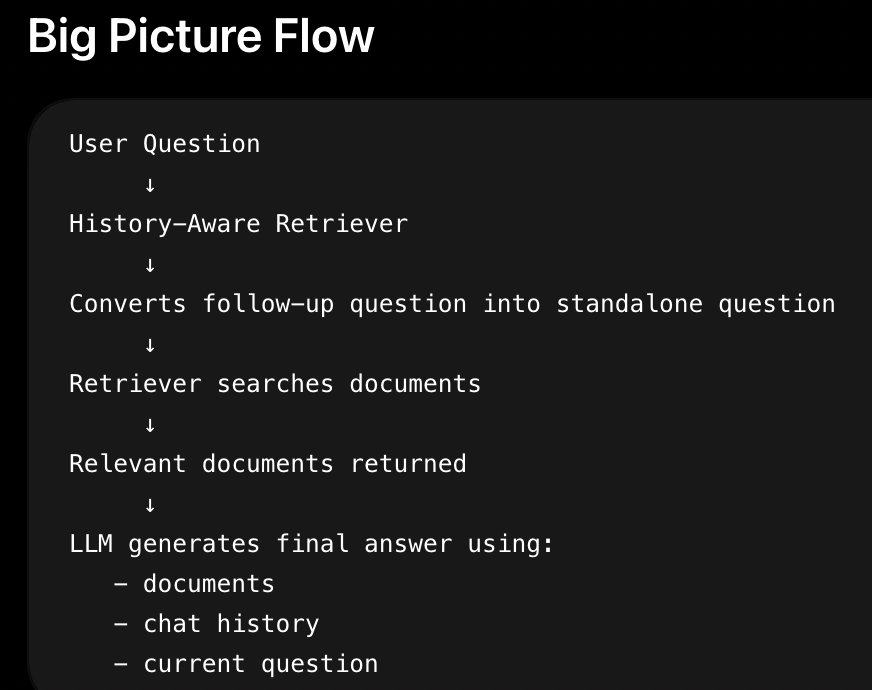

In [ ]:
from langchain_classic.chains import create_history_aware_retriever # Creates a retriever that can understand conversation history.
from langchain_core.prompts import MessagesPlaceholder # Acts as a placeholder for chat history inside prompts.

contextualize_q_system_prompt = (
    "Given a chat history and the latest user question "
    "which might reference context in the chat history, "
    "formulate a standalone question which can be understood "
    "without the chat history. Do NOT answer the question, "
    "just reformulate it if needed and otherwise return it as is."
)

# "Do not answer the question. Only rewrite it into a fully understandable standalone question."

contextualize_q_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", contextualize_q_system_prompt),
        MessagesPlaceholder("chat_history"),
        ("human", "{input}")
    ]
)


In [ ]:
history_aware_retriever = create_history_aware_retriever(llm, retriever, contextualize_q_prompt)
# llm -> rewrites follow-up questions

system_prompt = (
    "You are an assistant for question-answering tasks. "
    "Use the following pieces of retrieved context to answer "
    "the question. If you don't know the answer, say that you "
    "don't know. Use three sentences maximum and keep the "
    "answer concise."
    "\n\n"
    "{context}"
)

qa_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system_prompt),
        MessagesPlaceholder("chat_history"),
        ("human", "{input}")
    ]
)
# This prompt is used for final answering.

In [32]:
question_answer_chain = create_stuff_documents_chain(llm, qa_prompt) 
# All retrieved documents are “stuffed” into the prompt
rag_chain = create_retrieval_chain(history_aware_retriever, question_answer_chain)
# combines everything into one callable chain.

In [38]:
from langchain_core.messages import AIMessage, HumanMessage
chat_history = []
question1 = "What is Self-Reflection"
response1  = rag_chain.invoke(
    {
        "input" : question1,
        "chat_history" : chat_history
    }
)
response1["answer"]

'Self-Reflection is a vital aspect that allows autonomous agents to improve iteratively by refining past action decisions and correcting previous mistakes. It plays a crucial role in real-world tasks where trial and error are inevitable. Self-Reflection enables agents to analyze their past actions and adjust their behavior accordingly.'

In [ ]:
chat_history.extend(
    [
        HumanMessage(content=question1),
        AIMessage(content=response1["answer"]) 
    ]
)

question2 = "Tell me more about it"
response2 = rag_chain.invoke(
    {
        "input" : question2,
        "chat_history" : chat_history
    }
)
response2["answer"]

chat_history.extend(
    [
        HumanMessage(content=question2),
        AIMessage(content=response2["answer"]) 
    ]
)

"Self-Reflection is a process that involves analyzing past actions, identifying mistakes, and learning from them to make better decisions in the future. It's a crucial aspect of iterative improvement, especially in real-world tasks that involve trial and error. \n\nIn the context of autonomous agents, Self-Reflection is achieved through mechanisms that allow agents to reflect on their past actions, such as generating reasoning traces in natural language."

In [40]:
chat_history

[HumanMessage(content='What is Self-Reflection', additional_kwargs={}, response_metadata={}),
 AIMessage(content='Self-Reflection is a vital aspect that allows autonomous agents to improve iteratively by refining past action decisions and correcting previous mistakes. It plays a crucial role in real-world tasks where trial and error are inevitable. Self-Reflection enables agents to analyze their past actions and adjust their behavior accordingly.', additional_kwargs={}, response_metadata={})]

In [68]:
from langchain_community.chat_message_histories import ChatMessageHistory
from langchain_core.chat_history import BaseChatMessageHistory
from langchain_core.runnables.history import RunnableWithMessageHistory 

store = {}

def get_session_history(session_id : str) -> BaseChatMessageHistory:
    if session_id not in store:
        store[session_id] = ChatMessageHistory()
    return store[session_id]

conversational_rag_chain = RunnableWithMessageHistory(
    rag_chain,
    get_session_history,
    input_messages_key = "input",
    history_messages_key = "chat_history",
    output_messages_key = "answer",
)

In [70]:
config = {"configurable": {"session_id": "abc123"}}
response = conversational_rag_chain.invoke(
    {"input": "What is Task Decomposition?"},
    config=config
)
response["answer"]

'Task decomposition is the process of breaking down a complex task into a series of smaller, manageable subtasks or steps. This helps to simplify the task and make it easier to accomplish.'

In [71]:
response = conversational_rag_chain.invoke(
    {"input": "What are common ways of doing it?"},
    config=config
)
response["answer"]

'There are several common ways to do task decomposition, including using Large Language Models (LLM) with simple prompting, task-specific instructions, human inputs, and also using an external classical planner (LLM+P approach) with Planning Domain Definition Language (PDDL) as an intermediate interface.'